In [64]:
using Plots

In [65]:
# Get circle points
x = collect(-1:0.01:1)
y = sqrt.(1 .- x.^2)
x = append!(x, -x)
y = append!(y, -y)
z = [x y]'

2×402 adjoint(::Matrix{Float64}) with eltype Float64:
 -1.0  -0.99      -0.98      -0.97      -0.96  …  -0.98      -0.99      -1.0
  0.0   0.141067   0.198997   0.243105   0.28     -0.198997  -0.141067  -0.0

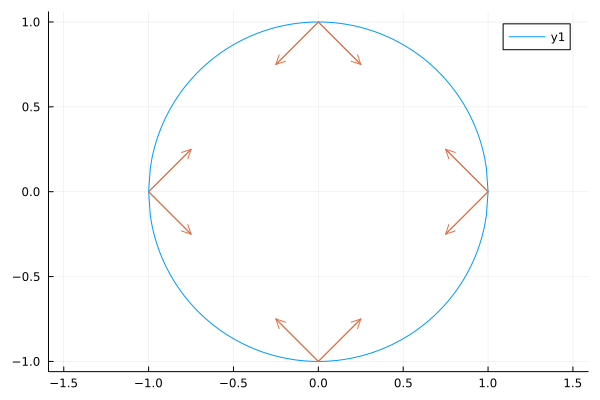

In [66]:
# Plot circle and perpendicular arrow vectors
plot(z[1,:], z[2,:], aspect_ratio=:equal)
v = [-1 -1 1 1 0 0 0 0;0 0 0 0 1 1 -1 -1]
Δv = [0.25 0.25 -0.25 -0.25 0.25 -0.25 0.25 -0.25;-0.25 0.25 0.25 -0.25 -0.25 -0.25 0.25 0.25]
quiver!(v[1,:], v[2,:], quiver=(Δv[1,:], Δv[2,:]))

In [67]:
# Transformation matrix
T = [2 0;0 1]
tz = T*z
v_trans = T*v
Δv_trans = T*Δv

2×8 Matrix{Float64}:
  0.5   0.5   -0.5   -0.5    0.5   -0.5   0.5   -0.5
 -0.25  0.25   0.25  -0.25  -0.25  -0.25  0.25   0.25

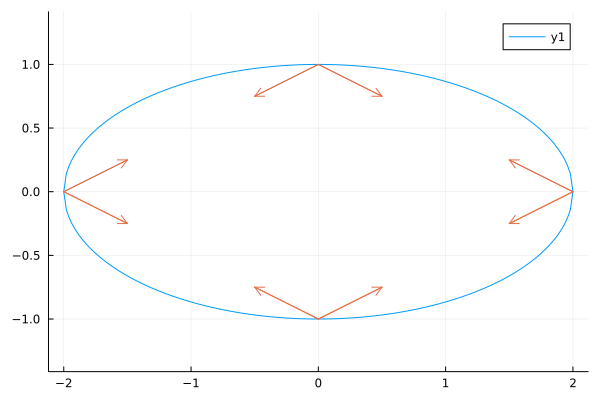

In [68]:
# Plot scaled circled and resulting arrow vectors
plot(tz[1,:], tz[2,:], aspect_ratio=:equal)
quiver!(v_trans[1,:], v_trans[2,:], quiver=(Δv_trans[1,:], Δv_trans[2,:]))

In [69]:
Δv'*Δv 

8×8 Matrix{Float64}:
  0.125   0.0    -0.125   0.0     0.125   0.0     0.0    -0.125
  0.0     0.125   0.0    -0.125   0.0    -0.125   0.125   0.0
 -0.125   0.0     0.125   0.0    -0.125   0.0     0.0     0.125
  0.0    -0.125   0.0     0.125   0.0     0.125  -0.125   0.0
  0.125   0.0    -0.125   0.0     0.125   0.0     0.0    -0.125
  0.0    -0.125   0.0     0.125   0.0     0.125  -0.125   0.0
  0.0     0.125   0.0    -0.125   0.0    -0.125   0.125   0.0
 -0.125   0.0     0.125   0.0    -0.125   0.0     0.0     0.125

In [91]:
#= 
Vectors are 'A' orthogonal, as shown by taking the dot product 
of 'unwarped' vectors 
=#
(inv(T)*Δv_trans)[:,1]'*(inv(T)*Δv_trans)[:,2]

# Result:
# 0.0

0.0

In [92]:
Δv_trans

2×8 Matrix{Float64}:
  0.5   0.5   -0.5   -0.5    0.5   -0.5   0.5   -0.5
 -0.25  0.25   0.25  -0.25  -0.25  -0.25  0.25   0.25

In [93]:
inv(T)*Δv_trans[:,:]

2×8 Matrix{Float64}:
  0.25  0.25  -0.25  -0.25   0.25  -0.25  0.25  -0.25
 -0.25  0.25   0.25  -0.25  -0.25  -0.25  0.25   0.25

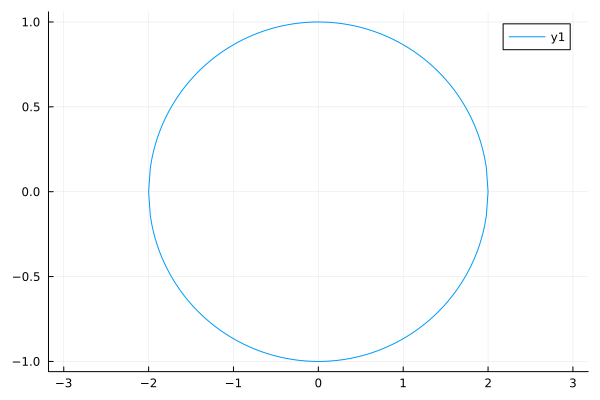

In [73]:
# scaled x-axis by 2
plot(tz[1,:], tz[2,:], aspect_ratio=:2)

In [94]:
function conjugate_grad(A, x, b)
    r = -(A*x-b)
    d = r 
    while sum(abs2.(r))>0.1
        α = d'*r/(d'*A*d)
        println(x.+α*d)
        println(α)
        x = x .+ α*d
        r = r .- α*A*d

        β = -r'*A*d/(d'*A*d)
        d = r .+ β*d
        println(β)
        println("r:",r)
    end
    x
end


conjugate_grad (generic function with 1 method)

In [100]:
conjugate_grad([4 1;1 3.], [45,1.],[1,2.])

[4.261940357227161, -9.41083746426417]
0.2263225535709602
0.020816994193039673
r:[-6.636923964644495, 25.97057203556534]
[0.09090909090908994, 0.6363636363636367]
0.4016793265837188
-4.387386080429377e-17
r:[-1.865174681370263e-14, -3.552713678800501e-15]


2-element Vector{Float64}:
 0.09090909090908994
 0.6363636363636367

In [96]:
function conjugate_grad2(A, x, b)
    r = -(A*x-b)
    d = r 
    while sum(abs2.(r))>0.1
        α = d'*r/(d'*A*d)
        println(x.+α*d)
        println(α)

        x = x .+ α*d
        r_new = r .- α*A*d

        β = r_new'*r_new/(r'*r)
        d = r_new .+ β*d

        r = r_new
        println(β)
        println("r:",r)
    end
    x
end


conjugate_grad2 (generic function with 1 method)

In [97]:
conjugate_grad2([4 1;1 3.], [-8,-8.], [1,2.])

[0.961248073959938, -0.5687211093990756]
0.21856702619414484
0.004482189026141918
r:[-2.276271186440681, 2.744915254237288]
[0.09090909090908939, 0.6363636363636365]
0.4159323228762778
3.101851013516526e-31
r:[1.7763568394002505e-15, 8.881784197001252e-16]


2-element Vector{Float64}:
 0.09090909090908939
 0.6363636363636365

In [101]:
function plot_quadf(A, b, c)
    x = -10:1:10
    y = -10:1:10
    t3 = []
    for i in x
        for j in y
            z = [i; j]
            f = 0.5*z'*A*z.-b'*z.+c
            push!(t3, f)
        end
    end
    contour(y, x, t3)
    plot!([-8, 0.961248073959938, 0.09090909090908283], [-8, -0.5687211093990756, 0.636], 2)
end


plot_quadf (generic function with 1 method)

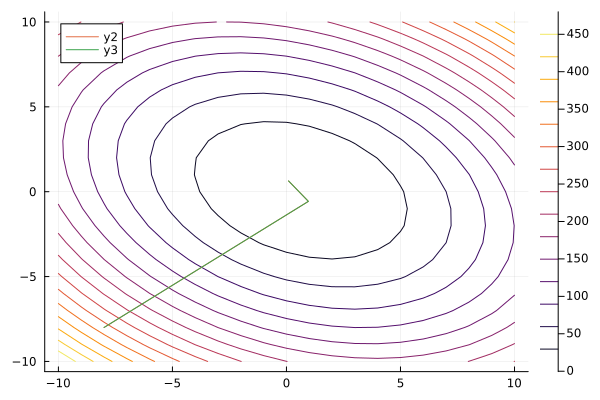

In [99]:
plot_quadf([4 1;1 3.], [1,2.], 0)
